In [1]:
import sys
import json
from pathlib import Path

raiz = Path.cwd()
if raiz.name == "notebooks":
    raiz = raiz.parent
sys.path.insert(0, str(raiz))

from lakehouse import Lakehouse
from analisis_comun import FILTRO, GRUPO_EDAD, ORDEN_EDAD

db = Lakehouse()
consultar = db.consultar
ejecutar = db.ejecutar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
from scipy.stats import spearmanr

figuras = raiz / "figuras"
figuras.mkdir(exist_ok=True)
EDAD_3 = {'10-14': '10-19', '15-19': '10-19', '20-34': '20-34',
          '35-39': '35+', '40-44': '35+', '45-60': '35+'}


def poligonos(archivo, campo):
    """Lista de (código, polígono) desde un GeoJSON de datos_referencia/."""
    with open(raiz / 'datos_referencia' / archivo) as f:
        capas = json.load(f)['features']
    salida = []
    for capa in capas:
        geometria = capa['geometry']
        partes = geometria['coordinates'] if geometria['type'] == 'MultiPolygon' else [geometria['coordinates']]
        salida += [(capa['properties'][campo], np.array(parte[0])) for parte in partes]
    return salida


PROVINCIAS = poligonos('peru_provincial_simple.geojson', 'FIRST_IDPR')
DEPARTAMENTOS = poligonos('peru_departamental_simple.geojson', 'FIRST_IDDP')


def mapa(ax, valores, titulo, etiqueta, limites=None, cmap='YlOrRd'):
    """Coropleta por provincia; gris = sin datos suficientes. Bordes gruesos = departamentos."""
    colores = plt.get_cmap(cmap).copy()
    colores.set_bad('#DDDDDD')
    provincias = PatchCollection([Polygon(p) for _, p in PROVINCIAS], cmap=colores,
                                 edgecolor='white', linewidth=0.2)
    provincias.set_array(np.ma.masked_invalid([valores.get(codigo, np.nan) for codigo, _ in PROVINCIAS]))
    if limites:
        provincias.set_clim(*limites)
    ax.add_collection(provincias)
    ax.add_collection(PatchCollection([Polygon(p) for _, p in DEPARTAMENTOS], facecolor='none',
                                      edgecolor='#444444', linewidth=0.5))
    ax.autoscale_view()
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(titulo)
    plt.colorbar(provincias, ax=ax, shrink=0.6, label=etiqueta)


def correlacion_ponderada(x, y, pesos):
    mx, my = np.average(x, weights=pesos), np.average(y, weights=pesos)
    cov = np.average((x - mx) * (y - my), weights=pesos)
    return cov / np.sqrt(np.average((x - mx) ** 2, weights=pesos) * np.average((y - my) ** 2, weights=pesos))

In [2]:
# 1. Prematuridad por provincia de residencia y edad de la madre
# Prematuro: menos de 37 semanas; muy prematuro: menos de 32 semanas
ejecutar(f"""CREATE OR REPLACE TABLE __CATALOGO__.analytics.prematuridad_provincia_edad
USING DELTA AS
SELECT substring(id_ubigeo_inei, 1, 4) AS codigo_provincia,
       ANY_VALUE(provincia) AS provincia,
       ANY_VALUE(departamento_residencia) AS departamento,
       ANY_VALUE(macroregion) AS macroregion,
       {GRUPO_EDAD} AS grupo_edad,
       COUNT(*) AS nacimientos,
       COUNT_IF(duracion_embarazo_semanas < 37) AS prematuros,
       COUNT_IF(duracion_embarazo_semanas < 32) AS muy_prematuros,
       COUNT_IF(es_bajo_peso_nacer) AS bajo_peso,
       COUNT_IF(es_bajo_peso_nacer AND duracion_embarazo_semanas < 37) AS bajo_peso_prematuro,
       COUNT_IF(duracion_embarazo_semanas >= 37) AS nacimientos_termino,
       COUNT_IF(es_bajo_peso_nacer AND duracion_embarazo_semanas >= 37) AS bajo_peso_termino,
       AVG(altitud_msnm) AS altitud_msnm,
       AVG(idh_2019) AS idh_2019,
       AVG(pobreza_pct) AS pobreza_pct
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO} AND id_ubigeo_inei IS NOT NULL
GROUP BY substring(id_ubigeo_inei, 1, 4), {GRUPO_EDAD}""")
detalle = consultar('SELECT * FROM __CATALOGO__.analytics.prematuridad_provincia_edad')
for columna in ['altitud_msnm', 'idh_2019', 'pobreza_pct']:
    detalle[columna] = pd.to_numeric(detalle[columna], errors='coerce')
print(f"{detalle['codigo_provincia'].nunique()} provincias, {detalle['nacimientos'].sum():,} partos únicos")

# Nacional: prematuridad por edad y cuánto del bajo peso es prematuro
edad = detalle.groupby('grupo_edad')[['nacimientos', 'prematuros', 'muy_prematuros']].sum().reindex(ORDEN_EDAD)
edad['% prematuros'] = (100 * edad['prematuros'] / edad['nacimientos']).round(2)
edad['% muy prematuros'] = (100 * edad['muy_prematuros'] / edad['nacimientos']).round(2)
print(edad.to_string())
totales = detalle[['nacimientos', 'prematuros', 'bajo_peso', 'bajo_peso_prematuro']].sum()
print(f"Prematuros: {100 * totales['prematuros'] / totales['nacimientos']:.2f} % de los partos únicos; "
      f"el {100 * totales['bajo_peso_prematuro'] / totales['bajo_peso']:.1f} % de los bajo peso son prematuros.")

196 provincias, 4,796,697 partos únicos
            nacimientos  prematuros  muy_prematuros  % prematuros  % muy prematuros
grupo_edad                                                                         
10-14             24959        2767             342         11.09              1.37
15-19            614497       38283            4817          6.23              0.78
20-34           3252148      173823           20605          5.34              0.63
35-39            669807       49222            5825          7.35              0.87
40-44            220641       19775            2464          8.96              1.12
45-60             14587        1835             247         12.58              1.69
Prematuros: 5.96 % de los partos únicos; el 59.7 % de los bajo peso son prematuros.


In [3]:
# 2. Indicadores por provincia, con tasa de prematuridad ajustada por edad (estandarización indirecta)
# Esperados = nacimientos de cada grupo de edad × tasa nacional de ese grupo.
# Razón > 1: más prematuros de lo que explica la edad de sus madres.
tasa_nacional = detalle.groupby('grupo_edad')['prematuros'].sum() / detalle.groupby('grupo_edad')['nacimientos'].sum()
detalle['prematuros_esperados'] = detalle['nacimientos'] * detalle['grupo_edad'].map(tasa_nacional)
detalle['edad_3'] = detalle['grupo_edad'].map(EDAD_3)
for columna in ['altitud_msnm', 'idh_2019', 'pobreza_pct']:
    detalle[f'{columna}_x_n'] = detalle[columna] * detalle['nacimientos']

provincias = detalle.groupby('codigo_provincia').agg(
    provincia=('provincia', 'first'), departamento=('departamento', 'first'),
    macroregion=('macroregion', 'first'), nacimientos=('nacimientos', 'sum'),
    prematuros=('prematuros', 'sum'), prematuros_esperados=('prematuros_esperados', 'sum'),
    nacimientos_termino=('nacimientos_termino', 'sum'), bajo_peso_termino=('bajo_peso_termino', 'sum'),
    altitud_msnm=('altitud_msnm_x_n', 'sum'), idh_2019=('idh_2019_x_n', 'sum'), pobreza_pct=('pobreza_pct_x_n', 'sum'))
for columna in ['altitud_msnm', 'idh_2019', 'pobreza_pct']:
    provincias[columna] = provincias[columna] / provincias['nacimientos']
por_edad = detalle.pivot_table(index='codigo_provincia', columns='edad_3', values='nacimientos', aggfunc='sum')
provincias['%_madres_10_19'] = 100 * por_edad['10-19'] / provincias['nacimientos']
provincias['%_madres_35_mas'] = 100 * por_edad['35+'] / provincias['nacimientos']
provincias['%_prematuros'] = 100 * provincias['prematuros'] / provincias['nacimientos']
provincias['razon_prematuros_ajustada_edad'] = provincias['prematuros'] / provincias['prematuros_esperados']
provincias['%_bajo_peso_termino'] = 100 * provincias['bajo_peso_termino'] / provincias['nacimientos_termino']

MINIMO = 1000  # provincias con menos partos quedan en gris en los mapas
confiables = provincias[provincias['nacimientos'] >= MINIMO]
print(f'{len(confiables)} de {len(provincias)} provincias con al menos {MINIMO} partos')
columnas = ['provincia', 'departamento', 'nacimientos', '%_prematuros', 'razon_prematuros_ajustada_edad',
            '%_madres_10_19', '%_madres_35_mas', 'altitud_msnm']
print('\nMás prematuros (ajustado por edad):')
print(confiables.sort_values('razon_prematuros_ajustada_edad', ascending=False)[columnas].head(12).round(2).to_string())
print('\nMenos prematuros (ajustado por edad):')
print(confiables.sort_values('razon_prematuros_ajustada_edad')[columnas].head(8).round(2).to_string())
(raiz / 'resultados').mkdir(exist_ok=True)
provincias.to_csv(raiz / 'resultados' / 'prematuridad_provincias.csv')

191 de 196 provincias con al menos 1000 partos

Más prematuros (ajustado por edad):
                              provincia departamento  nacimientos  %_prematuros  razon_prematuros_ajustada_edad  %_madres_10_19  %_madres_35_mas  altitud_msnm
codigo_provincia                                                                                                                                              
1601                             MAYNAS       LORETO       105101          8.93                            1.50           21.52            14.33        117.66
2504                              PURUS      UCAYALI         1015          8.97                            1.46           24.83            14.98        228.00
2209                         SAN MARTIN   SAN MARTÍN        33787          8.20                            1.39           15.25            15.94        333.16
2007                             TALARA        PIURA        18889          7.75                            1.32          

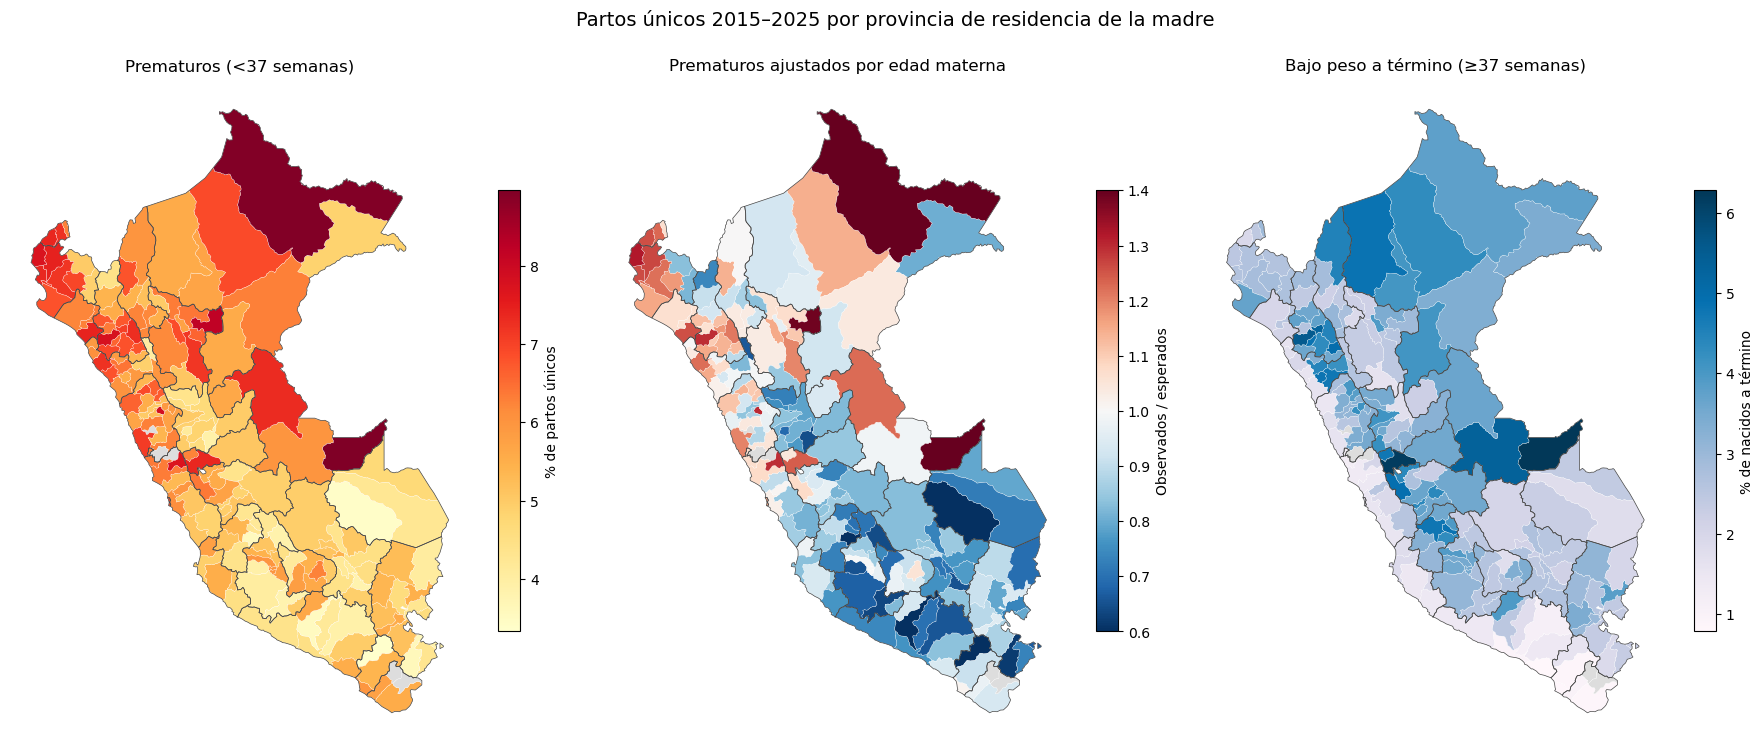

In [4]:
# 3. Mapas: prematuridad (cruda y ajustada por edad) frente a bajo peso a término
fig, ejes = plt.subplots(1, 3, figsize=(18, 8))
mapa(ejes[0], confiables['%_prematuros'].to_dict(), 'Prematuros (<37 semanas)', '% de partos únicos')
mapa(ejes[1], confiables['razon_prematuros_ajustada_edad'].to_dict(),
     'Prematuros ajustados por edad materna', 'Observados / esperados', limites=(0.6, 1.4), cmap='RdBu_r')
mapa(ejes[2], confiables['%_bajo_peso_termino'].to_dict(), 'Bajo peso a término (≥37 semanas)',
     '% de nacidos a término', cmap='PuBu')
fig.suptitle('Partos únicos 2015–2025 por provincia de residencia de la madre', fontsize=14)
fig.tight_layout()
fig.savefig(figuras / 'mapa_prematuridad.png', dpi=180)
plt.show()

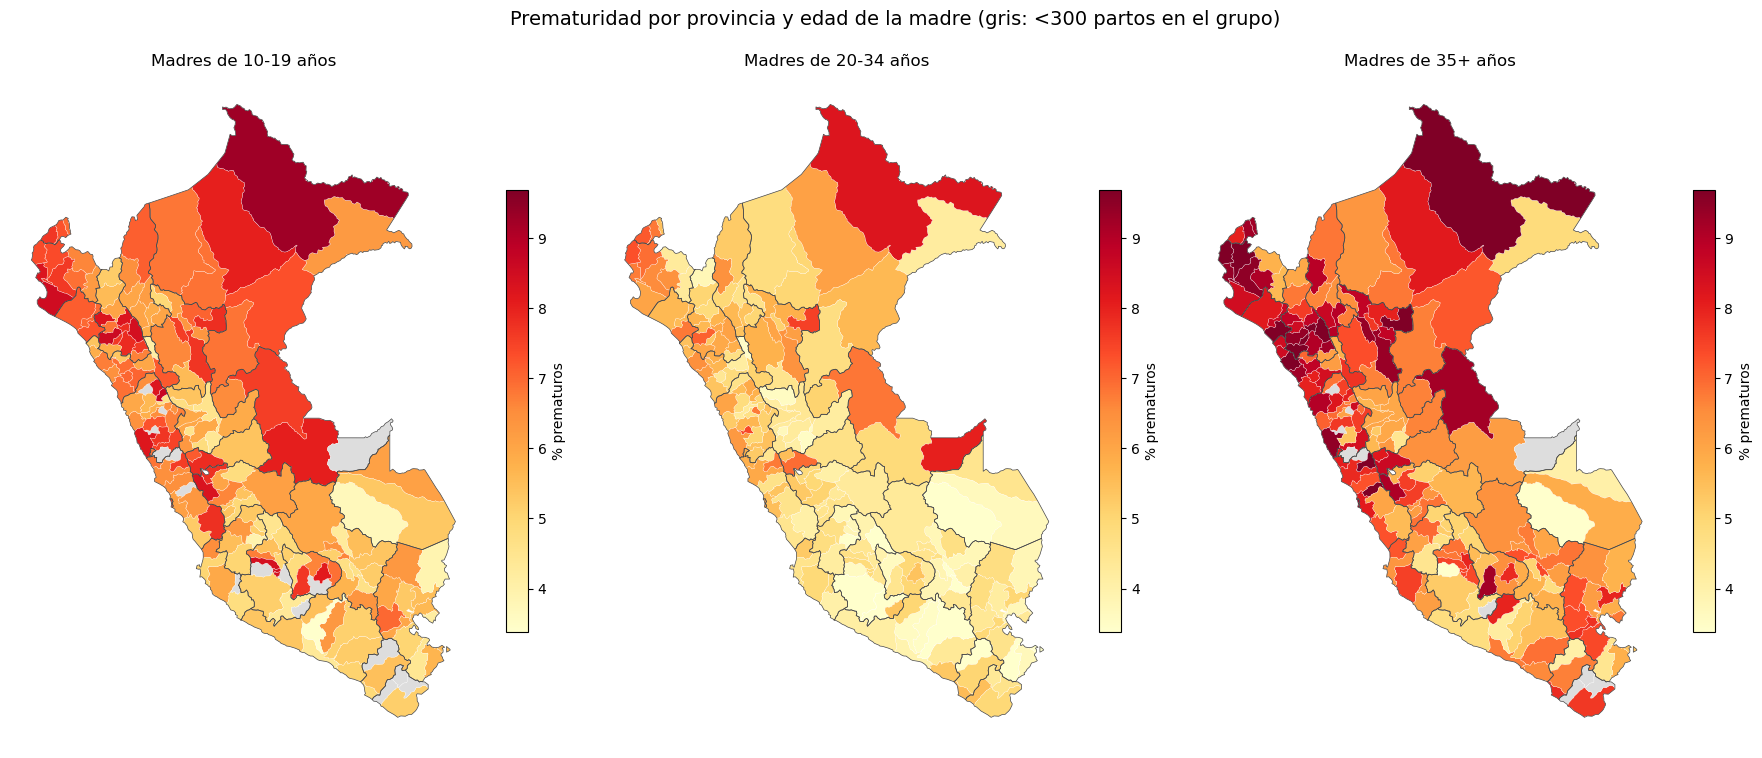

% prematuros por macrorregión y edad de la madre:
edad_3               10-19  20-34   35+  RR 10-19 vs 20-34  RR 35+ vs 20-34
macroregion                                                                
LIMA Y CALLAO         6.30   5.51  8.12               1.14             1.47
MACROREGION CENTRO    5.56   4.49  6.43               1.24             1.43
MACROREGION NORTE     6.91   5.93  8.71               1.17             1.47
MACROREGION ORIENTE   7.37   6.28  8.73               1.17             1.39
MACROREGION SUR       5.46   4.34  6.76               1.26             1.56


In [5]:
# 4. Mapas de prematuridad por grupo de edad de la madre (misma escala)
grupos = detalle.groupby(['codigo_provincia', 'edad_3'])[['nacimientos', 'prematuros']].sum()
grupos = grupos[grupos['nacimientos'] >= 300]
grupos['%'] = 100 * grupos['prematuros'] / grupos['nacimientos']
limites = tuple(np.nanpercentile(grupos['%'], [2, 98]))
fig, ejes = plt.subplots(1, 3, figsize=(18, 8))
for ax, grupo in zip(ejes, ['10-19', '20-34', '35+']):
    valores = grupos.xs(grupo, level='edad_3')['%'].to_dict()
    mapa(ax, valores, f'Madres de {grupo} años', '% prematuros', limites=limites)
fig.suptitle('Prematuridad por provincia y edad de la madre (gris: <300 partos en el grupo)', fontsize=14)
fig.tight_layout()
fig.savefig(figuras / 'mapa_prematuridad_por_edad.png', dpi=180)
plt.show()

# El efecto de la edad dentro de cada macrorregión (riesgo relativo frente a 20-34 años)
macro = detalle.groupby(['macroregion', 'edad_3'])[['nacimientos', 'prematuros']].sum()
macro = (100 * macro['prematuros'] / macro['nacimientos']).unstack()[['10-19', '20-34', '35+']]
macro['RR 10-19 vs 20-34'] = macro['10-19'] / macro['20-34']
macro['RR 35+ vs 20-34'] = macro['35+'] / macro['20-34']
print('% prematuros por macrorregión y edad de la madre:')
print(macro.round(2).to_string())

Nacimientos por edad y primer embarazo:
primeriza   Primeriza  No primeriza
grupo_edad                         
10-14           23825           700
15-19          474085        131792
20-34          879409       2346797
35-39           56455        609002
40-44           12209        207058
45-60            1569         12921

Tasas por edad (RR = primeriza / no primeriza):
           % prematuros                    % bajo peso                    % bajo peso a término                   
primeriza     Primeriza No primeriza    RR   Primeriza No primeriza    RR             Primeriza No primeriza    RR
grupo_edad                                                                                                        
10-14             11.08        10.57  1.05       11.56         9.86  1.17                  5.46         3.99  1.37
15-19              6.25         6.19  1.01        7.46         5.99  1.25                  3.76         2.61  1.44
20-34              5.15         5.42  0.95      

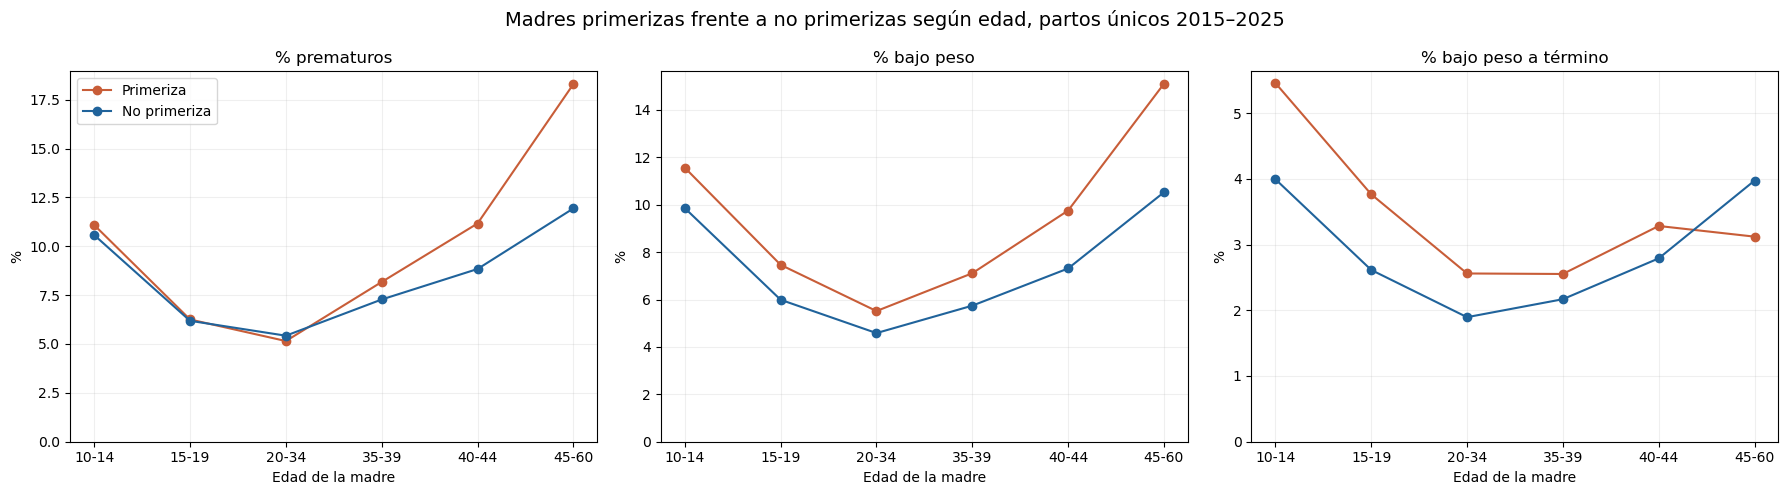

In [6]:
# 4b. Madres primerizas (primer embarazo) × edad: prematuridad, bajo peso y bajo peso a término
PRIMERIZA = """CASE WHEN num_embar_madre_cat = '1' THEN 'Primeriza'
            WHEN num_embar_madre_cat IS NULL THEN 'SIN DATO'
            ELSE 'No primeriza' END"""
primerizas = consultar(f"""
SELECT {GRUPO_EDAD} AS grupo_edad,
       {PRIMERIZA} AS primeriza,
       COALESCE(macroregion, 'SIN DATO') AS macroregion,
       COUNT(*) AS nacimientos,
       COUNT_IF(duracion_embarazo_semanas < 37) AS prematuros,
       COUNT_IF(es_bajo_peso_nacer) AS bajo_peso,
       COUNT_IF(duracion_embarazo_semanas >= 37) AS nacimientos_termino,
       COUNT_IF(es_bajo_peso_nacer AND duracion_embarazo_semanas >= 37) AS bajo_peso_termino
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO}
GROUP BY ALL
""")
primerizas = primerizas[primerizas['primeriza'] != 'SIN DATO']
TASAS = {'% prematuros': ('prematuros', 'nacimientos'), '% bajo peso': ('bajo_peso', 'nacimientos'),
         '% bajo peso a término': ('bajo_peso_termino', 'nacimientos_termino')}


def tasas_primeriza(por):
    suma = primerizas.groupby([por, 'primeriza'])[['nacimientos', 'prematuros', 'bajo_peso',
                                                   'nacimientos_termino', 'bajo_peso_termino']].sum()
    salida = {}
    for nombre, (casos, total) in TASAS.items():
        tabla = (100 * suma[casos] / suma[total]).unstack()[['Primeriza', 'No primeriza']]
        tabla['RR'] = tabla['Primeriza'] / tabla['No primeriza']
        salida[nombre] = tabla
    return pd.concat(salida, axis=1), suma['nacimientos'].unstack()


por_edad, n_edad = tasas_primeriza('grupo_edad')
por_edad, n_edad = por_edad.reindex(ORDEN_EDAD), n_edad.reindex(ORDEN_EDAD)
print('Nacimientos por edad y primer embarazo:')
print(n_edad[['Primeriza', 'No primeriza']].to_string())
print('\nTasas por edad (RR = primeriza / no primeriza):')
print(por_edad.round(2).to_string())
por_macro, _ = tasas_primeriza('macroregion')
print('\nTasas por macrorregión:')
print(por_macro.drop(index='SIN DATO', errors='ignore').round(2).to_string())

fig, ejes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
for ax, nombre in zip(ejes, TASAS):
    for grupo, color in [('Primeriza', '#C85D38'), ('No primeriza', '#20639B')]:
        ax.plot(ORDEN_EDAD, por_edad[nombre][grupo], marker='o', color=color, label=grupo)
    ax.set(title=nombre, xlabel='Edad de la madre', ylabel='%')
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.2)
ejes[0].legend()
fig.suptitle('Madres primerizas frente a no primerizas según edad, partos únicos 2015–2025', fontsize=14)
fig.tight_layout()
fig.savefig(figuras / 'primerizas_edad.png', dpi=180)
plt.show()

          resultado                 factor  provincias  spearman  p_valor  pearson_ponderado
         Prematuros % madres de 10-19 años         191     0.001    0.993             -0.010
         Prematuros   % madres de 35+ años         191     0.046    0.528             -0.045
         Prematuros   Altitud media (msnm)         191    -0.403    0.000             -0.527
         Prematuros               IDH 2019         191     0.218    0.002              0.286
         Prematuros            Pobreza (%)         191    -0.128    0.077             -0.224
Bajo peso a término % madres de 10-19 años         191     0.503    0.000              0.698
Bajo peso a término   % madres de 35+ años         191    -0.172    0.017             -0.562
Bajo peso a término   Altitud media (msnm)         191     0.356    0.000              0.477
Bajo peso a término               IDH 2019         191    -0.586    0.000             -0.719
Bajo peso a término            Pobreza (%)         191     0.594    0.

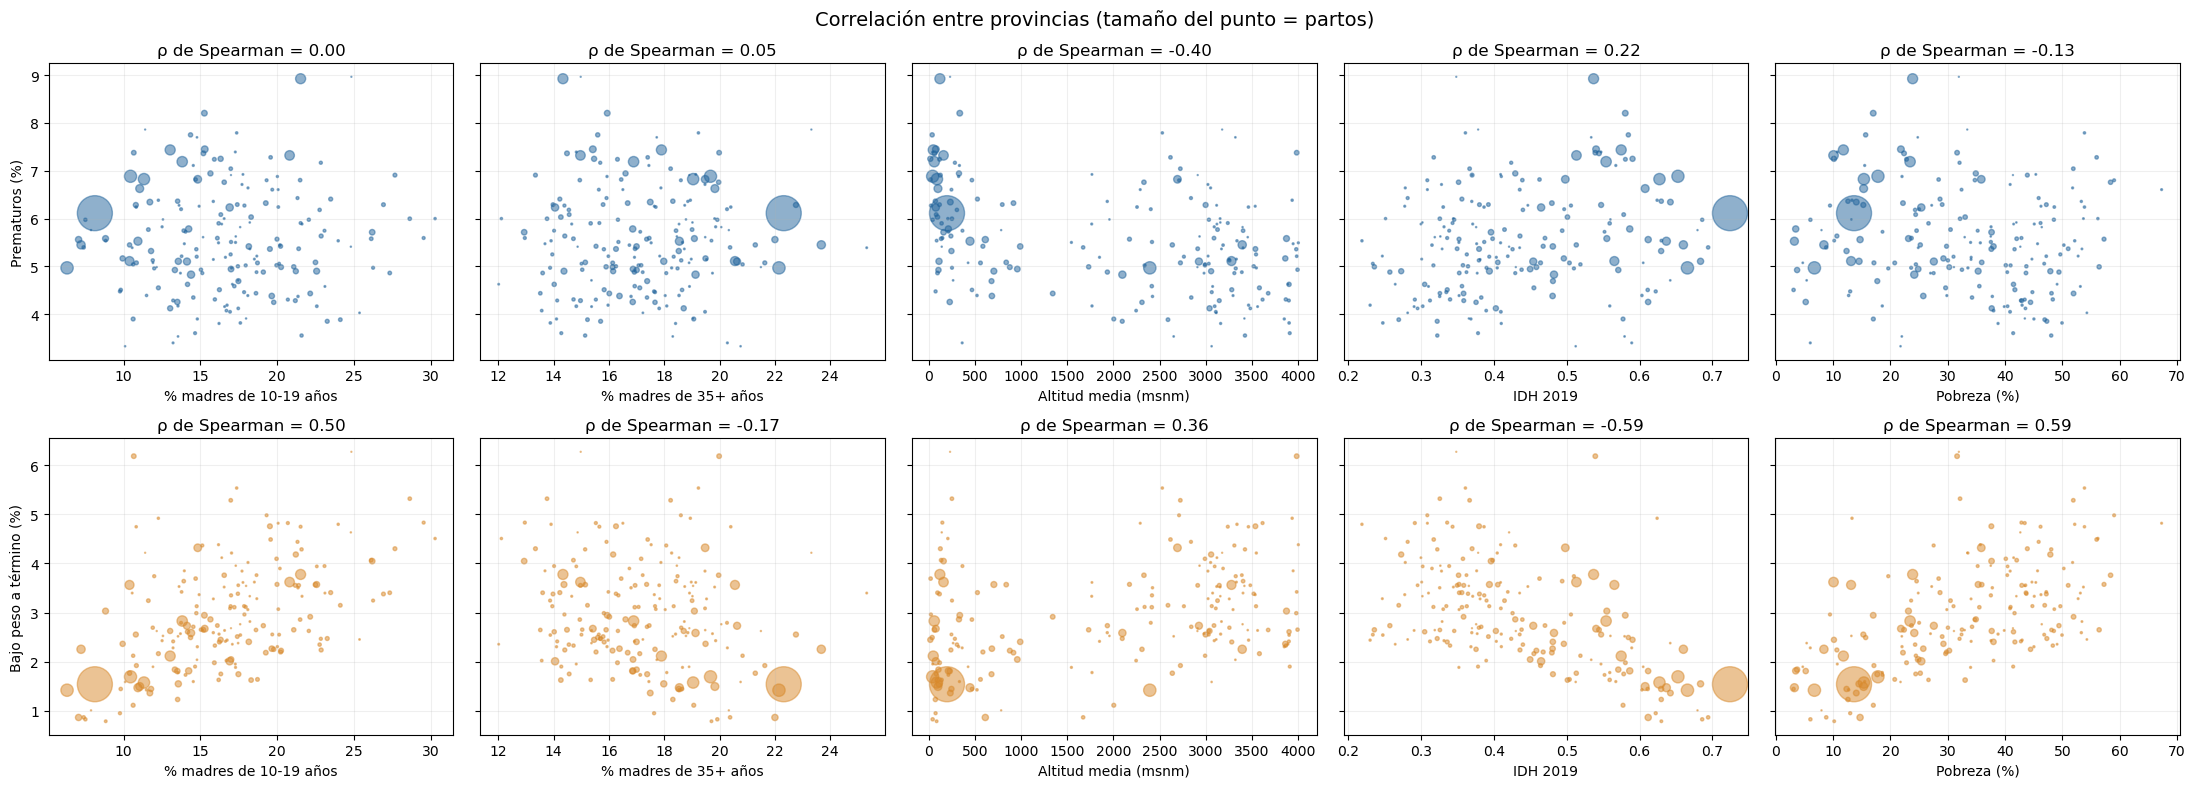

In [7]:
# 5. Correlaciones entre provincias (ecológicas): ¿qué acompaña a la prematuridad?
factores = {'%_madres_10_19': '% madres de 10-19 años', '%_madres_35_mas': '% madres de 35+ años',
            'altitud_msnm': 'Altitud media (msnm)', 'idh_2019': 'IDH 2019', 'pobreza_pct': 'Pobreza (%)'}
resultados_prov = {'%_prematuros': 'Prematuros', '%_bajo_peso_termino': 'Bajo peso a término'}
filas, rhos = [], {}
for resultado, nombre in resultados_prov.items():
    for factor, etiqueta in factores.items():
        datos = confiables[[resultado, factor, 'nacimientos']].dropna()
        rho, p = spearmanr(datos[resultado], datos[factor])
        rhos[resultado, factor] = rho
        filas.append({'resultado': nombre, 'factor': etiqueta, 'provincias': len(datos),
                      'spearman': rho, 'p_valor': p,
                      'pearson_ponderado': correlacion_ponderada(datos[resultado], datos[factor], datos['nacimientos'])})
correlaciones = pd.DataFrame(filas)
print(correlaciones.round(3).to_string(index=False))

fig, ejes = plt.subplots(2, len(factores), figsize=(22, 8), sharey='row')
for fila, (resultado, nombre) in enumerate(resultados_prov.items()):
    for ax, (factor, etiqueta) in zip(ejes[fila], factores.items()):
        ax.scatter(confiables[factor], confiables[resultado], s=confiables['nacimientos'] / 2000,
                   alpha=0.5, color='#20639B' if fila == 0 else '#D8892B')
        ax.set_title(f'ρ de Spearman = {rhos[resultado, factor]:.2f}')
        ax.set_xlabel(etiqueta)
        ax.grid(alpha=0.2)
    ejes[fila][0].set_ylabel(f'{nombre} (%)')
fig.suptitle('Correlación entre provincias (tamaño del punto = partos)', fontsize=14)
fig.tight_layout()
fig.savefig(figuras / 'correlaciones_provincias.png', dpi=180)
plt.show()

                        Bajo peso  Prematuros  Muy prematuros  Prematuros ajust. edad  Bajo peso a término  Madres 10-19  Madres 35+  Altitud  IDH 2019  Pobreza
Bajo peso                    1.00        0.43            0.27                    0.42                 0.94          0.44       -0.16     0.24     -0.45     0.50
Prematuros                   0.43        1.00            0.74                    1.00                 0.17          0.00        0.05    -0.40      0.22    -0.13
Muy prematuros               0.27        0.74            1.00                    0.74                 0.04         -0.07        0.12    -0.43      0.27    -0.17
Prematuros ajust. edad       0.42        1.00            0.74                    1.00                 0.15         -0.02        0.04    -0.40      0.24    -0.14
Bajo peso a término          0.94        0.17            0.04                    0.15                 1.00          0.50       -0.17     0.36     -0.59     0.59
Madres 10-19                 0.44 

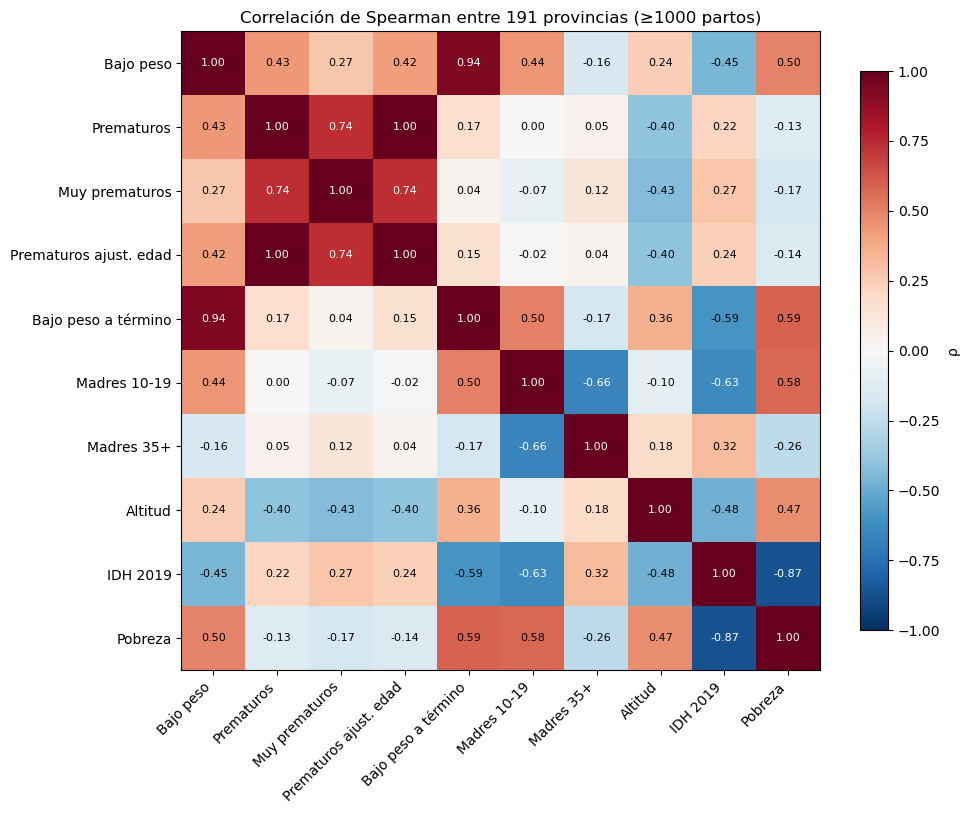

In [8]:
# 5b. Matriz de correlación de Spearman entre indicadores de las provincias
provincias['%_bajo_peso'] = 100 * detalle.groupby('codigo_provincia')['bajo_peso'].sum() / provincias['nacimientos']
provincias['%_muy_prematuros'] = 100 * detalle.groupby('codigo_provincia')['muy_prematuros'].sum() / provincias['nacimientos']
confiables = provincias[provincias['nacimientos'] >= MINIMO]
indicadores = {'%_bajo_peso': 'Bajo peso', '%_prematuros': 'Prematuros', '%_muy_prematuros': 'Muy prematuros',
               'razon_prematuros_ajustada_edad': 'Prematuros ajust. edad', '%_bajo_peso_termino': 'Bajo peso a término',
               '%_madres_10_19': 'Madres 10-19', '%_madres_35_mas': 'Madres 35+', 'altitud_msnm': 'Altitud',
               'idh_2019': 'IDH 2019', 'pobreza_pct': 'Pobreza'}
matriz = confiables[list(indicadores)].rename(columns=indicadores).corr(method='spearman')
print(matriz.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 8.5))
imagen = ax.imshow(matriz, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(matriz)), matriz.columns, rotation=45, ha='right')
ax.set_yticks(range(len(matriz)), matriz.index)
for (i, j), valor in np.ndenumerate(matriz.to_numpy()):
    ax.text(j, i, f'{valor:.2f}', ha='center', va='center', fontsize=8,
            color='white' if abs(valor) > 0.6 else 'black')
ax.set_title(f'Correlación de Spearman entre {len(confiables)} provincias (≥{MINIMO} partos)')
plt.colorbar(imagen, ax=ax, shrink=0.8, label='ρ')
fig.tight_layout()
fig.savefig(figuras / 'matriz_correlacion_provincias.png', dpi=180)
plt.show()

In [9]:
# 6. Resumen
print(f"Prematuridad por edad (nivel individual): {edad.loc['10-14', '% prematuros']:.1f} % en 10-14 años, "
      f"{edad.loc['20-34', '% prematuros']:.1f} % en 20-34 y {edad.loc['45-60', '% prematuros']:.1f} % en 45-60.")
print(f"Entre provincias, el % de madres adolescentes casi no se correlaciona con la prematuridad "
      f"(ρ = {rhos['%_prematuros', '%_madres_10_19']:.2f}): la edad actúa en cada madre, "
      f"pero no explica las diferencias geográficas.")
print(f"Altitud: ρ = {rhos['%_prematuros', 'altitud_msnm']:.2f} con prematuros y "
      f"ρ = {rhos['%_bajo_peso_termino', 'altitud_msnm']:.2f} con bajo peso a término: "
      f"dos mecanismos con geografías distintas.")
print('Las correlaciones son ecológicas (entre provincias) y no deben interpretarse para cada madre.')

Prematuridad por edad (nivel individual): 11.1 % en 10-14 años, 5.3 % en 20-34 y 12.6 % en 45-60.
Entre provincias, el % de madres adolescentes casi no se correlaciona con la prematuridad (ρ = 0.00): la edad actúa en cada madre, pero no explica las diferencias geográficas.
Altitud: ρ = -0.40 con prematuros y ρ = 0.36 con bajo peso a término: dos mecanismos con geografías distintas.
Las correlaciones son ecológicas (entre provincias) y no deben interpretarse para cada madre.
